In [38]:
import os
import sys
os.chdir('/zhome/71/c/146676/main/')
sys.path.append('/zhome/71/c/146676/main/')
import numpy as np
import matplotlib.pyplot as plt
import h5py
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm  # ✅ Recommended for notebooks
import math
import importlib
from interactive_notebooks.n21_attachment import *
importlib.reload(sys.modules['interactive_notebooks.n21_attachment'])
from interactive_notebooks.n21_attachment import *
from interactive_notebooks.n23_attachment import *
importlib.reload(sys.modules['interactive_notebooks.n23_attachment'])
from interactive_notebooks.n23_attachment import *
from interactive_notebooks.n24_attachment import *
importlib.reload(sys.modules['interactive_notebooks.n24_attachment'])
from interactive_notebooks.n24_attachment import *
import itertools
from sklearn.cluster import KMeans

In [6]:
slice_index = 0, 72
start, stop = slice_index
with h5py.File("/dtu-compute/msaca/sliceA_diffraction/abs_volume/overview_abs_volume.h5", "r") as f:
    # List all groups and datasets
    print("Keys:", list(f.keys()))
    
    # Access a dataset (replace 'dataset_name' with an actual name from the keys)
    dataset_abs = f["absorption"]
    DA_2 = dataset_abs[:,130:230]
    DA_2 = DA_2.transpose([1,2,0])
    print(DA_2.shape)

absorption = DA_2[:,:,start:stop]
object_mask = absorption>0.002


Keys: ['absorption']
(100, 362, 71)


In [117]:
with h5py.File('/dtu-compute/msaca/sliceA_diffraction/own_reconstructions/material_decompositions/material_decomp2.h5', 'r') as f:
    materials = {key: f[key][:,:,:] for key in f.keys()}
# Sort keys for consistent ordering
material_names = sorted(materials.keys())

# Stack into array of shape (num_materials, X, Y, Z)
stacked = np.stack([materials[k] for k in material_names], axis=0)

# Normalize so that each voxel vector sums to 1
# shape: (num_materials, X, Y, Z)
sum_per_voxel = np.sum(stacked, axis=0, keepdims=True)  # shape: (1, X, Y, Z)
stacked_normalized = stacked / (sum_per_voxel + 1e-8)  # avoid divide-by-zero

# Optional: update the dictionary with normalized layers
materials = {
    key: stacked_normalized[i]*object_mask for i, key in enumerate(material_names)
}

num_materials = len(material_names)

stacked = np.stack([materials[k] for k in material_names], axis=0)
# Flatten masked voxels only → shape (num_materials, N_valid_voxels)
masked_data = stacked[:, object_mask]

In [118]:
import h5py
import numpy as np

# Group definitions
mineral_groups = [
    ['Albite', 'Orthoclase', 'Enstatite', 'Ferrosilite', 'Diopside', 'Forsterite'],  # Silicates
    ['Magnetite', 'Ilmenite', 'Hematite', 'Wüstite'],                                 # Oxides
    ['Chlorapatite', 'Pyrite'],                                                       # Phosphates/Sulfides
    ['Zircon', 'Baddeleyite', 'Rutile', 'Spinel']                                     # Accessory Minerals
]


mineral_groups = [
    ['Albite', 'Orthoclase', 'Enstatite', 'Ferrosilite', 'Diopside', 'Forsterite'],  # Silicates
    ['Magnetite'], ['Ilmenite'], ['Hematite'], ['Wüstite'],                                 # Oxides
    ['Chlorapatite'], ['Pyrite'],                                                       # Phosphates/Sulfides
    ['Zircon'], ['Baddeleyite'], ['Rutile'], ['Spinel']                                     # Accessory Minerals
]

group_names = ['Silicates', 'Oxides', 'Phosphates_Sulfides', 'Accessory_Minerals']
group_names = ['Silicates', 'Magnetite', 'Ilmenite', 'Hematite', 'Wüstite', 'Chlorapatite', 'Pyrite', 'Zircon', 'Baddeleyite', 'Rutile', 'Spinel']

# Initialize results
group_dict = {}
group_list = []

# Process each group
for group_name, mineral_list in zip(group_names, mineral_groups):
    stacked = np.stack([materials[mineral] for mineral in mineral_list], axis=0)  # (N_group, X, Y, Z)
    group_sum = np.sum(stacked, axis=0)  # (X, Y, Z)
    group_dict[group_name] = group_sum
    group_list.append(group_sum)

# Stack into array: (4, X, Y, Z)
group_array = np.stack(group_list, axis=0)

group_masked_data = group_array[:, object_mask]

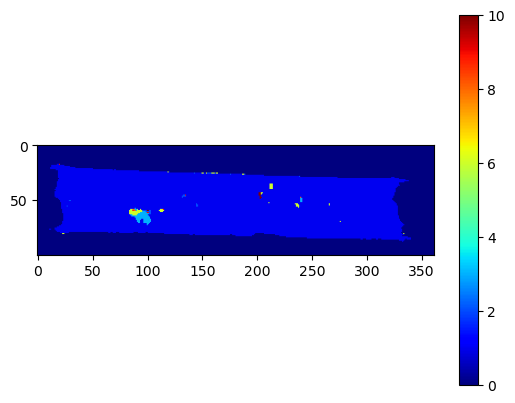

In [119]:
segm = (np.argmax(group_array, axis=0)+1)*object_mask
plt.imshow(segm[:,:,40], cmap='jet')
plt.colorbar()

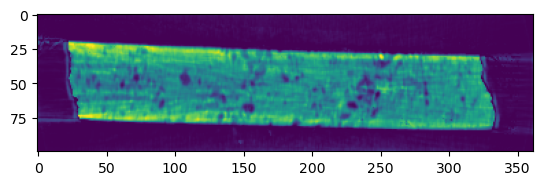

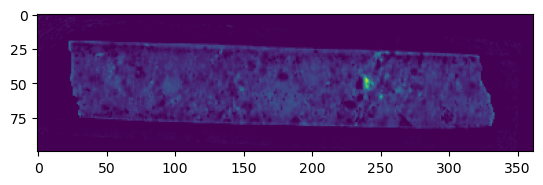

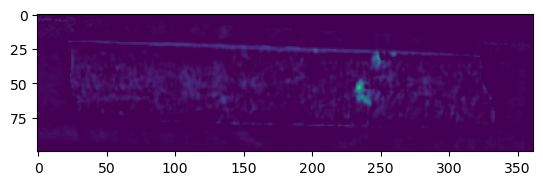

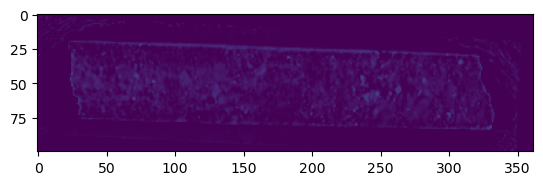

In [120]:
plt.imshow(grouped_materials['Silicates'][:,:,20], )
plt.clim([0,0.2])
plt.show()
plt.imshow(grouped_materials['Oxides'][:,:,20], )
plt.clim([0,0.2])
plt.show()
plt.imshow(grouped_materials['Phosphates_Sulfides'][:,:,20], )
plt.clim([0,0.2])
plt.show()
plt.imshow(grouped_materials['Accessory_Minerals'][:,:,20], )
plt.clim([0,0.2])
plt.show()

In [121]:
# Sum per material
total_per_material = masked_data.sum(axis=1)
total_all = total_per_material.sum()

volume_fractions = total_per_material / total_all

# Print or plot
for name, frac in zip(material_names, volume_fractions):
    print(f"{name}: {frac:.3%}")


Albite: 18.055%
Baddeleyite: 1.883%
Chlorapatite: 2.972%
Diopside: 19.366%
Enstatite: 14.179%
Ferrosilite: 8.864%
Forsterite: 4.625%
Hematite: 0.716%
Ilmenite: 2.981%
Magnetite: 12.102%
Orthoclase: 8.250%
Pyrite: 1.350%
Rutile: 1.183%
Spinel: 1.370%
Wüstite: 0.916%
Zircon: 1.190%


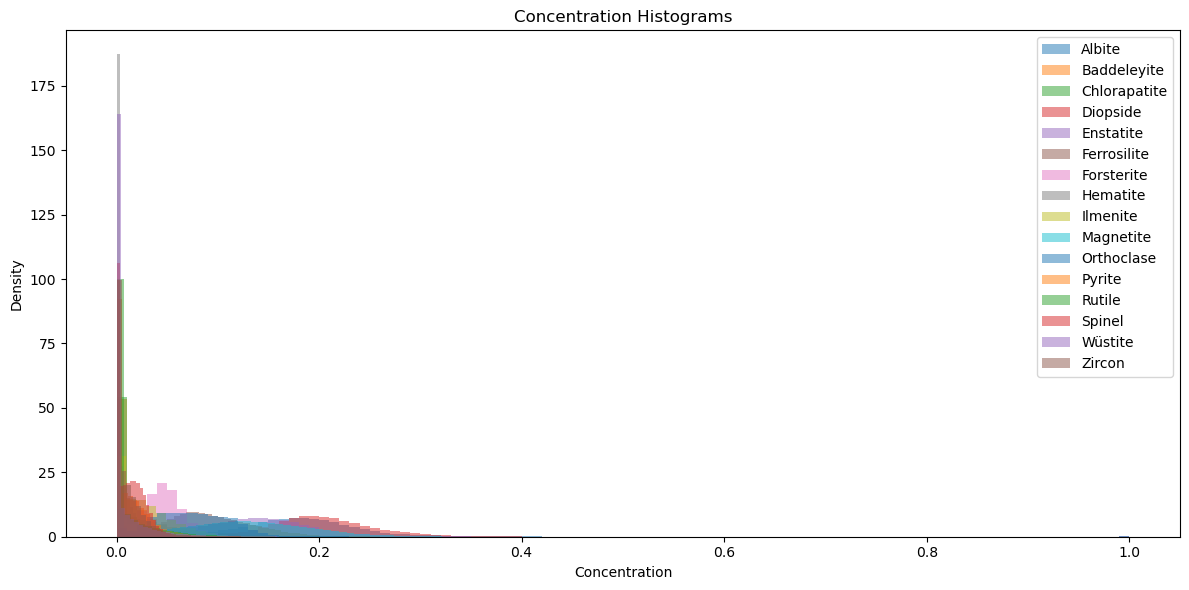

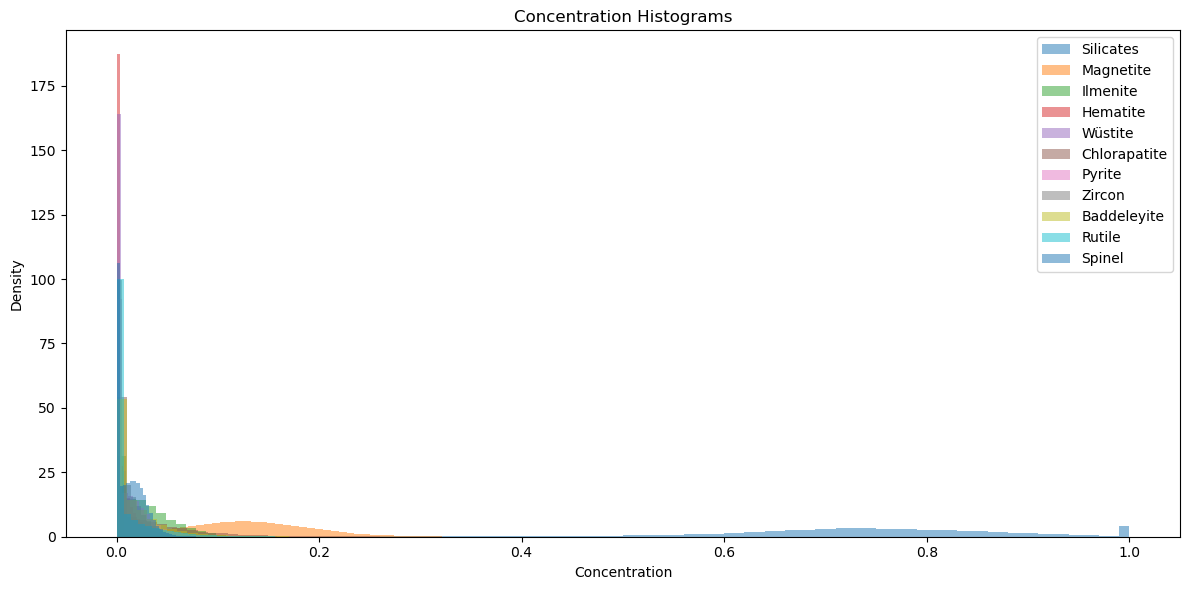

In [122]:
plt.figure(figsize=(12, 6))
for i, name in enumerate(material_names):
    plt.hist(masked_data[i], bins=100, alpha=0.5, label=name, density=True)
plt.title("Concentration Histograms")
plt.xlabel("Concentration")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))
for i, name in enumerate(group_names):
    plt.hist(group_masked_data[i], bins=100, alpha=0.5, label=name, density=True)
plt.title("Concentration Histograms")
plt.xlabel("Concentration")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


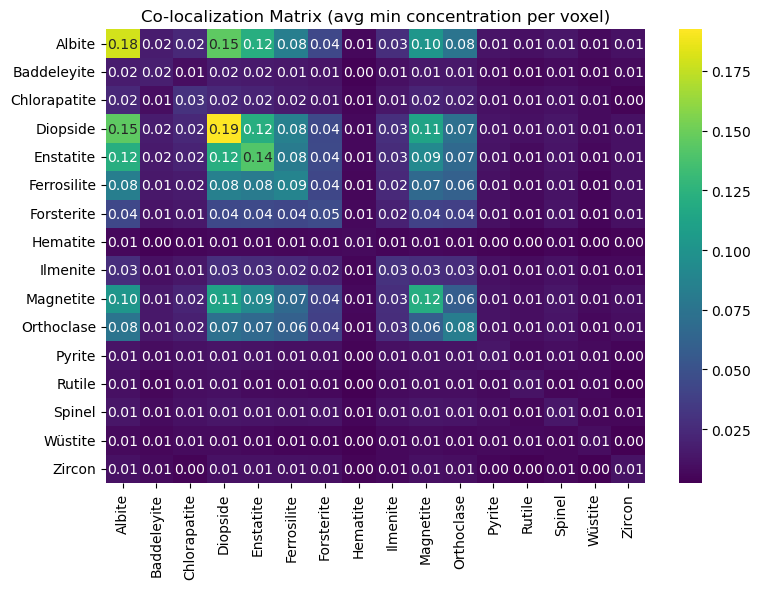

In [123]:
co_local_matrix = np.zeros((num_materials, num_materials), dtype=np.float32)

for i, j in itertools.combinations_with_replacement(range(num_materials), 2):
    overlap = np.minimum(masked_data[i], masked_data[j]).sum()
    co_local_matrix[i, j] = overlap
    co_local_matrix[j, i] = overlap  # symmetric

# Normalize by total voxels for interpretability
co_local_matrix /= masked_data.shape[1]

# Plot
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(co_local_matrix, xticklabels=material_names, yticklabels=material_names, cmap='viridis', annot=True, fmt=".2f")
plt.title("Co-localization Matrix (avg min concentration per voxel)")
plt.tight_layout()
plt.show()


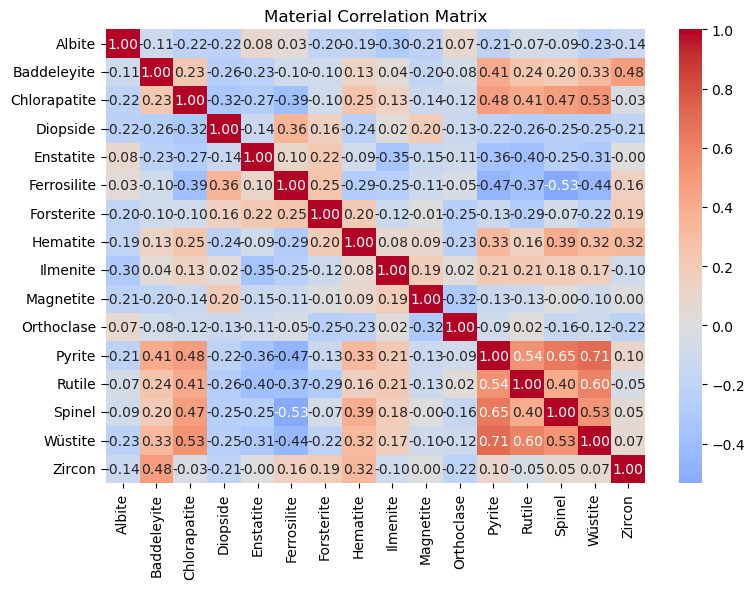

In [124]:
correlation_matrix = np.corrcoef(masked_data)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, xticklabels=material_names, yticklabels=material_names, cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.title("Material Correlation Matrix")
plt.tight_layout()
plt.show()


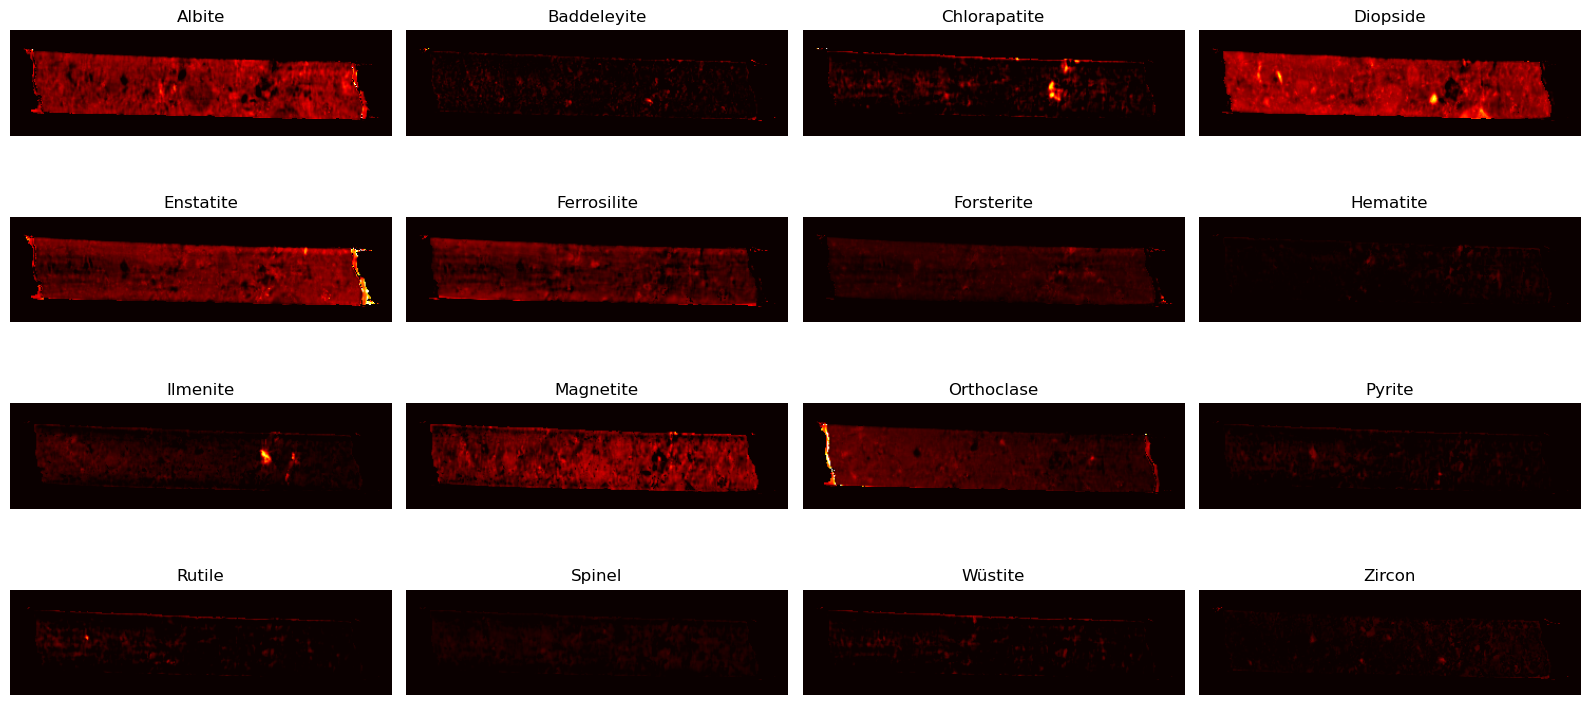

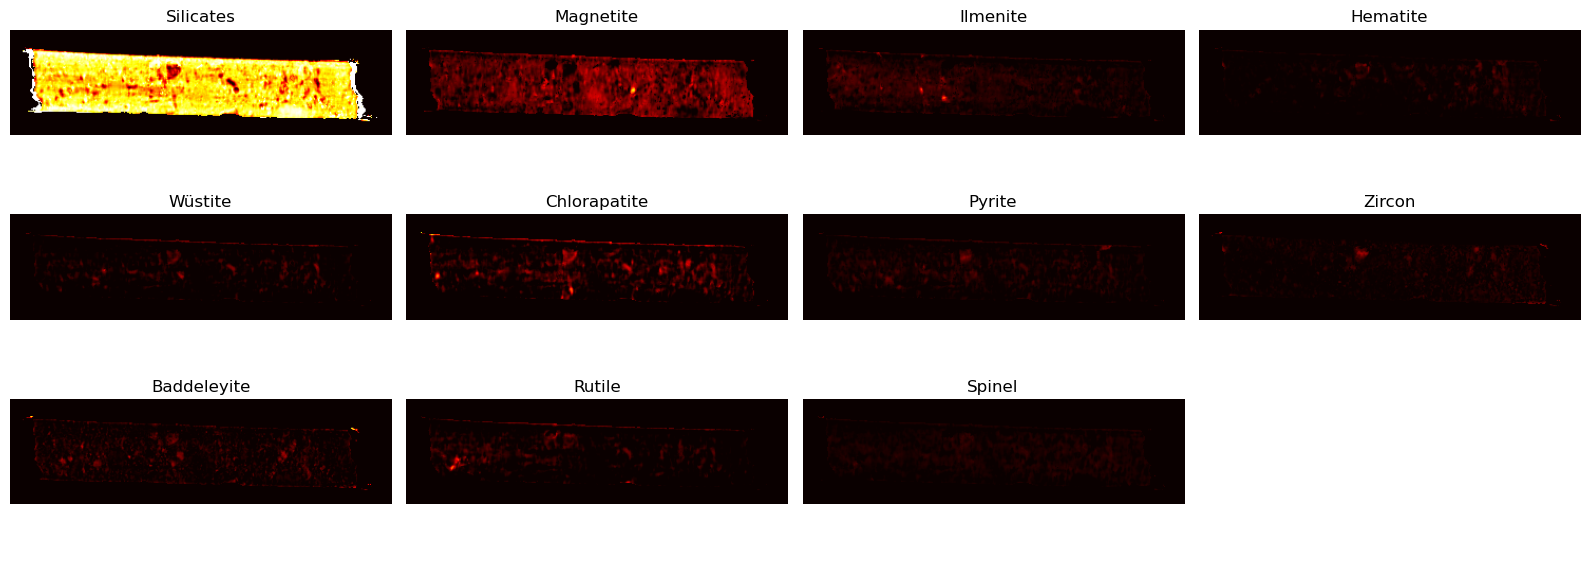

In [130]:
z_slice = 20
cols = 4
material_names = sorted(materials.keys())
num_materials = len(material_names)
volume_shape = next(iter(materials.values())).shape
rows = int(np.ceil(num_materials / cols))

fig, axs = plt.subplots(rows, cols, figsize=(4*cols, 4*rows//2))

for i, name in enumerate(material_names):
    row, col = divmod(i, cols)
    ax = axs[row, col]
    slice_ = materials[name][:, :, z_slice]
    ax.imshow(slice_, cmap='hot', vmin=0, vmax=1)
    ax.set_title(name)
    ax.axis('off')

# Turn off unused axes
for j in range(num_materials, rows * cols):
    axs.flat[j].axis('off')

plt.tight_layout()
plt.show()



z_slice = 30
cols = 4
num_materials = len(group_names)
volume_shape = next(iter(group_dict.values())).shape
rows = int(np.ceil(num_materials / cols))

fig, axs = plt.subplots(rows, cols, figsize=(4*cols, 4*rows//2))

for i, name in enumerate(group_names):
    row, col = divmod(i, cols)
    ax = axs[row, col]
    slice_ = group_dict[name][:, :, z_slice]
    ax.imshow(slice_, cmap='hot', vmin=0, vmax=1)
    ax.set_title(name)
    ax.axis('off')

# Turn off unused axes
for j in range(num_materials, rows * cols):
    axs.flat[j].axis('off')

plt.tight_layout()
plt.show()

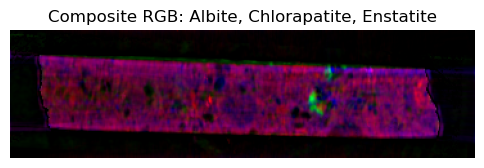

In [77]:
m1, m2, m3 = material_names[:6:2]  # Pick any 3 materials
s1 = materials[m1][:, :, z_slice]
s2 = materials[m2][:, :, z_slice]
s3 = materials[m3][:, :, z_slice]

# Normalize and stack into RGB image
def normalize(arr): return arr / (arr.max() + 1e-8)
rgb = np.stack([normalize(s1), normalize(s2), normalize(s3)], axis=-1)

plt.figure(figsize=(6, 6))
plt.imshow(rgb)
plt.title(f"Composite RGB: {m1}, {m2}, {m3}")
plt.axis('off')
plt.show()

2025-05-30 13:06:22.473 (   8.664s) [    7FB55DC7C740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=
/dtu-compute/msaca/conda3/envs/cil6/lib/python3.12/site-packages/pyvista/jupyter/notebook.py:36: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


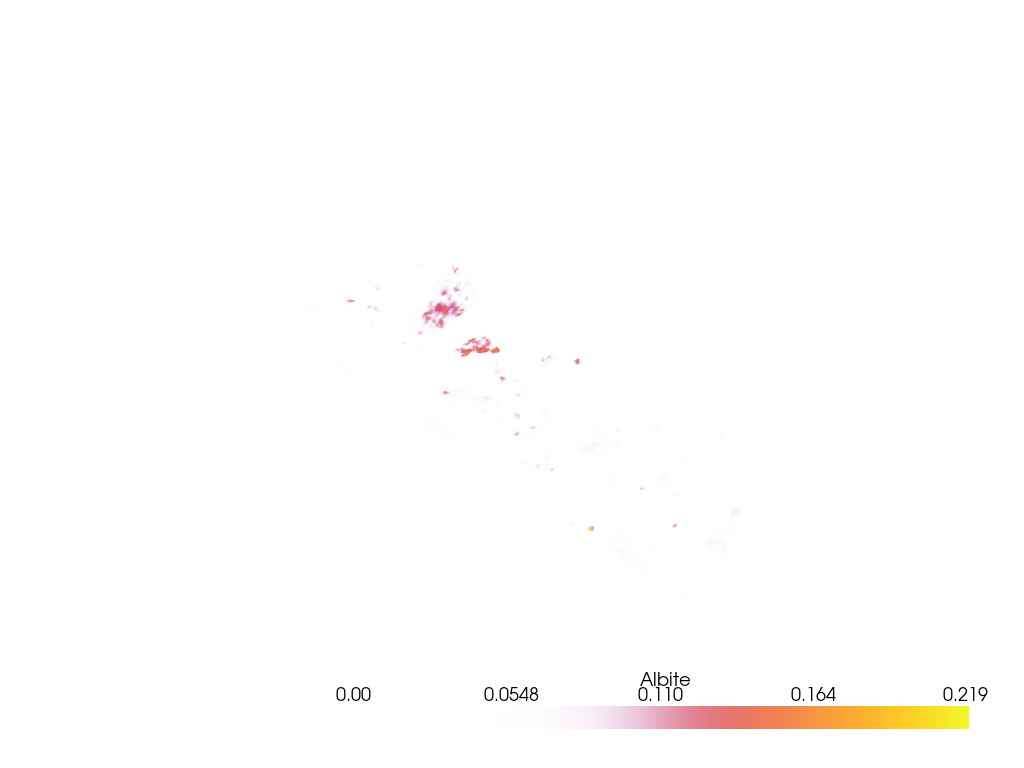

In [78]:
import pyvista as pv

# Choose a material
name = material_names[0]
vol = materials[name].copy()
vol[~object_mask] = 0

grid = pv.wrap(vol)
plotter = pv.Plotter()
plotter.add_volume(grid, cmap='plasma', opacity='sigmoid', scalar_bar_args={'title': name})
plotter.show()


/dtu-compute/msaca/conda3/envs/cil6/lib/python3.12/site-packages/pyvista/jupyter/notebook.py:36: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


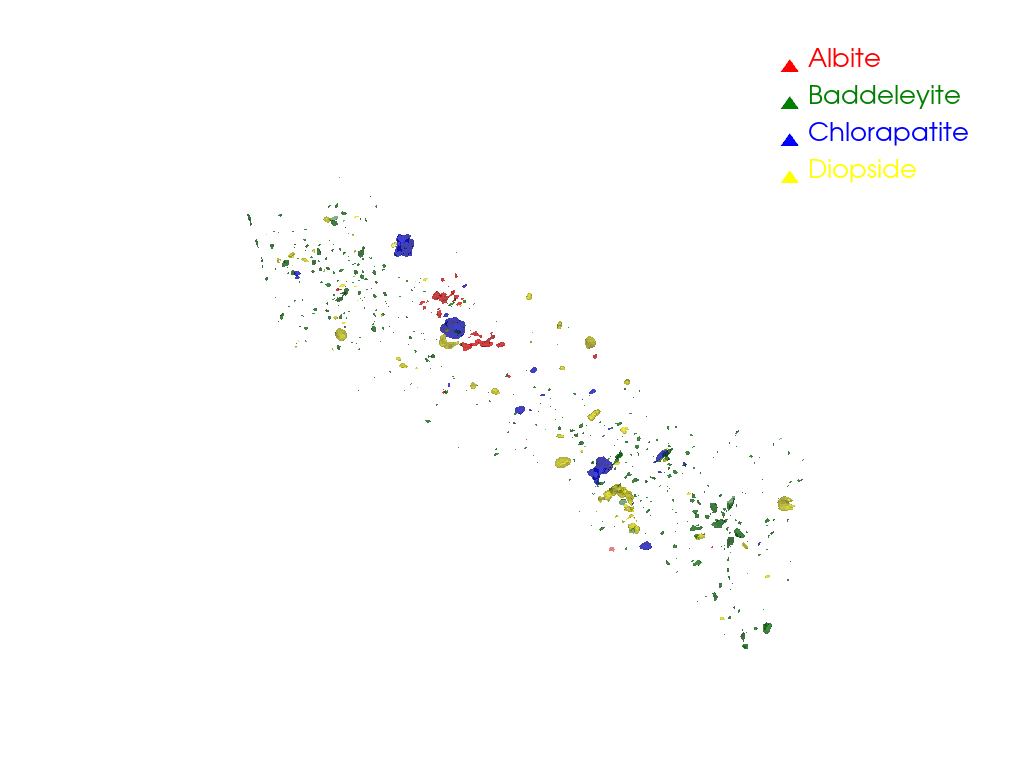

In [79]:
plotter = pv.Plotter()
colors = ['red', 'green', 'blue', 'yellow', 'purple', 'cyan', 'orange', 'magenta']

for i, name in enumerate(material_names[:4]):
    vol = materials[name].copy()
    vol[~object_mask] = 0
    grid = pv.wrap(vol)
    contour = grid.contour([vol.max() * 0.5])
    plotter.add_mesh(contour, color=colors[i % len(colors)], opacity=0.5, label=name)

plotter.add_legend()
plotter.show()


In [31]:
import nibabel as nib

# Stack in order: (X, Y, Z, M)
material_names = sorted(materials.keys())
volumes = [materials[name] for name in material_names]
stacked_4d = np.stack(volumes, axis=-1).astype(np.float32)

# Optional: Set voxel spacing (e.g., (sx, sy, sz))
affine = np.diag([1.0, 1.0, 1.0, 1.0])  # Replace with actual spacing if known

nii = nib.Nifti1Image(stacked_4d, affine)
nib.save(nii, '/dtu-compute/msaca/sliceA_diffraction/own_reconstructions/material_decompositions/material_decomp2.nii.gz')

In [32]:
print(material_names)

['Albite', 'Baddeleyite', 'Chlorapatite', 'Diopside', 'Enstatite', 'Ferrosilite', 'Forsterite', 'Hematite', 'Ilmenite', 'Magnetite', 'Orthoclase', 'Pyrite', 'Rutile', 'Spinel', 'Wüstite', 'Zircon']


In [33]:
mean_concentrations = {}

for name, vol in materials.items():
    mean_val = vol[object_mask].mean()
    mean_concentrations[name] = mean_val
    print(f"{name}: {mean_val:.4f}")


Albite: 0.0237
Baddeleyite: 0.0022
Chlorapatite: 0.0035
Diopside: 0.0268
Enstatite: 0.0183
Ferrosilite: 0.0123
Forsterite: 0.0062
Hematite: 0.0009
Ilmenite: 0.0041
Magnetite: 0.0168
Orthoclase: 0.0102
Pyrite: 0.0016
Rutile: 0.0014
Spinel: 0.0017
Wüstite: 0.0010
Zircon: 0.0015
